<a href="https://colab.research.google.com/github/Pangoa1992/PRACTICA-WILLY/blob/main/PRECIOS%20DE%20MERCADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning
import torch
import torch.nn as nn
import tensorflow as tf
from tensorflow import keras
from keras import layers

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


In [4]:
# 2. Ejemplo: cargar dataset (puede ser de Kaggle, aquí usamos CSV ficticio)
df = pd.read_csv("financial_data.csv")  # dataset con precios de mercado
print(df.head())

# Preprocesamiento
df = df.dropna()
X = df.drop("trend", axis=1)   # Variables predictoras
y = df["trend"]                # Variable objetivo (sube/baja)


       price  volume trend
0  97.013165    1805  down
1  85.967350    3523  down
2  48.909621    6205  down
3  37.176671    3825    up
4  59.974902    5007  down


In [3]:
# Create a sample financial_data.csv file
data = {'price': np.random.rand(100) * 100,
        'volume': np.random.randint(1000, 10000, 100),
        'trend': np.random.choice(['up', 'down'], 100)}
sample_df = pd.DataFrame(data)
sample_df.to_csv('financial_data.csv', index=False)

Reporte Clasificación:
              precision    recall  f1-score   support

        down       0.62      0.33      0.43        15
          up       0.17      0.40      0.24         5

    accuracy                           0.35        20
   macro avg       0.40      0.37      0.34        20
weighted avg       0.51      0.35      0.38        20



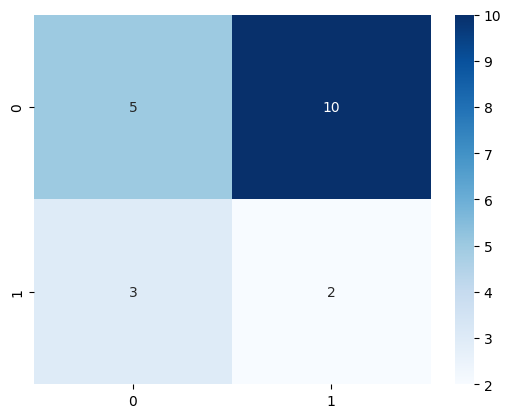

In [5]:
# 3. Machine Learning con Scikit-learn
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Reporte Clasificación:")
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues")
plt.show()


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 454ms/step - accuracy: 0.3958 - loss: 0.7003 - val_accuracy: 0.4375 - val_loss: 0.6840
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.4271 - loss: 0.6928 - val_accuracy: 0.6875 - val_loss: 0.6819
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6771 - loss: 0.6833 - val_accuracy: 0.6875 - val_loss: 0.6792
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.6667 - loss: 0.6810 - val_accuracy: 0.6250 - val_loss: 0.6787
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.6458 - loss: 0.6800 - val_accuracy: 0.5625 - val_loss: 0.6765
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6667 - loss: 0.6730 - val_accuracy: 0.5625 - val_loss: 0.6752
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.6771 - loss: 0.6692 - val_accuracy: 0.5625 - val_loss: 0.6737
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.6667 - loss: 0.6675 - val_accuracy: 0.5625 - val_loss: 0.6734
Epo

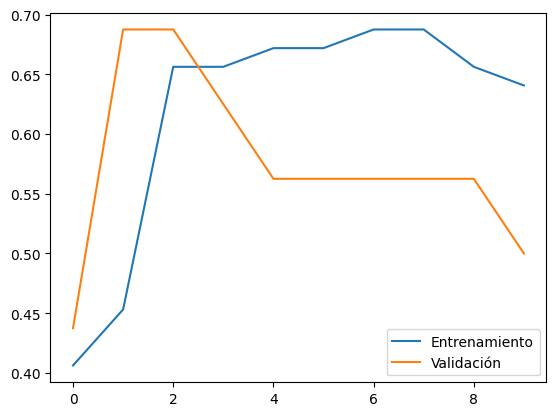

In [8]:
# 4. Deep Learning con Keras (ejemplo simple)

# Encode the target variable
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Reshape y_train_encoded for Keras
y_train_encoded = y_train_encoded.reshape(-1, 1)
y_test_encoded = y_test_encoded.reshape(-1, 1)


nn_model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

nn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = nn_model.fit(X_train, y_train_encoded, epochs=10, validation_split=0.2)

plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.legend()
plt.show()

In [12]:
# 5. Procesamiento de Lenguaje Natural
nltk.download("all") # Download all NLTK data to ensure all dependencies are met

texto = "El reporte financiero muestra crecimiento positivo en ingresos."
tokens = word_tokenize(texto.lower(), language='spanish')
tokens_filtrados = [w for w in tokens if w not in stopwords.words("spanish")]
print("Tokens filtrados:", tokens_filtrados)

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

Tokens filtrados: ['reporte', 'financiero', 'muestra', 'crecimiento', 'positivo', 'ingresos', '.']


[nltk_data]    |   Unzipping corpora/ycoe.zip.
[nltk_data]    | 
[nltk_data]  Done downloading collection all


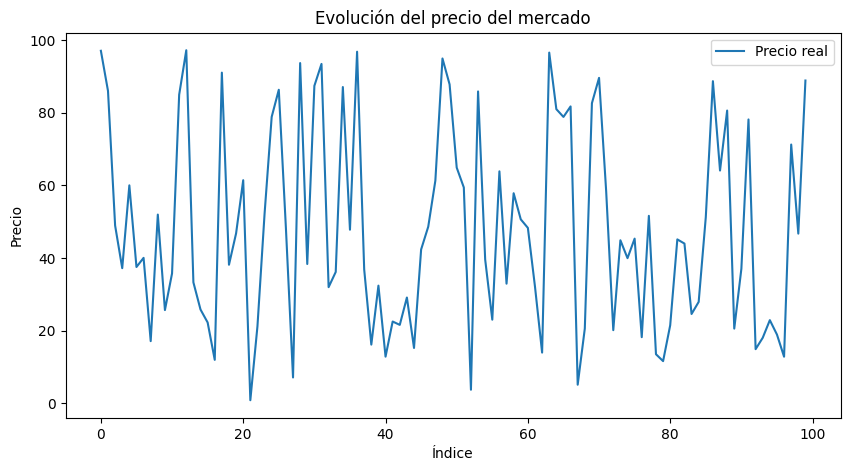

In [14]:
# 6. Visualización de tendencias
plt.figure(figsize=(10,5))
plt.plot(df.index, df["price"], label="Precio real")
plt.xlabel("Índice") # Change label to reflect using index
plt.ylabel("Precio")
plt.title("Evolución del precio del mercado")
plt.legend()
plt.show()